# 🏏 PSL ML Project
## Notebook 4: Model Training & Evaluation
**Task:** Binary Classification — 1st innings batting team jeetegi ya nahi?
Hum multiple models train karein ge aur compare karein ge.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
import joblib

df = pd.read_csv('E:\PSL_Predictor\data\psl_match_features.csv')
print('✅ Processed data loaded! Shape:', df.shape)

✅ Processed data loaded! Shape: (311, 28)


### Step 1: Features aur Target Select karo

In [4]:
# Features select karo (only 1st innings stats — jo 2nd innings start se pehle known hain)
FEATURES = [
    'batting_team_enc', 'bowling_team_enc', 'venue_enc', 'season',
    'inn1_total_runs', 'inn1_wickets', 'inn1_extras',
    'inn1_sixes', 'inn1_fours', 'inn1_dot_balls',
    'inn1_pp_runs', 'inn1_pp_wickets',
    'inn1_death_runs', 'inn1_death_wickets',
    'inn1_run_rate', 'inn1_boundary_pct', 'inn1_dot_ball_pct',
    'pp_run_rate', 'death_run_rate'
]

TARGET = 'target'

X = df[FEATURES]
y = df[TARGET]

print('Feature matrix shape:', X.shape)
print('Target distribution:')
print(y.value_counts(normalize=True).round(3))
print('\nFeatures used:')
for f in FEATURES:
    print(f'  - {f}')

Feature matrix shape: (311, 19)
Target distribution:
target
0    0.556
1    0.444
Name: proportion, dtype: float64

Features used:
  - batting_team_enc
  - bowling_team_enc
  - venue_enc
  - season
  - inn1_total_runs
  - inn1_wickets
  - inn1_extras
  - inn1_sixes
  - inn1_fours
  - inn1_dot_balls
  - inn1_pp_runs
  - inn1_pp_wickets
  - inn1_death_runs
  - inn1_death_wickets
  - inn1_run_rate
  - inn1_boundary_pct
  - inn1_dot_ball_pct
  - pp_run_rate
  - death_run_rate


### Step 2: Train-Test Split

In [5]:
# Stratified split — class balance maintain karo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')

# Feature scaling (Logistic Regression aur SVM ke liye zaroori)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('\n✅ Data scaled!')

Training set: 248 samples
Test set:     63 samples

✅ Data scaled!


### Step 3: Multiple Models Train Karo

In [6]:
# 5 different models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Models train ho rahe hain...')
print('='*60)

for name, model in models.items():
    # Scaled data use karo LR aur SVM ke liye
    if name in ['Logistic Regression', 'SVM']:
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train.values, X_test.values
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='accuracy')
    
    # Train on full training set
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    
    test_acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        'model': model,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_accuracy': test_acc,
        'auc_roc': auc,
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    
    print(f'{name:25s} | CV: {cv_scores.mean():.3f}±{cv_scores.std():.3f} | Test Acc: {test_acc:.3f} | AUC: {auc:.3f}')

print('\n✅ All models trained!')

Models train ho rahe hain...
Logistic Regression       | CV: 0.758±0.029 | Test Acc: 0.587 | AUC: 0.650
Decision Tree             | CV: 0.665±0.039 | Test Acc: 0.667 | AUC: 0.627
Random Forest             | CV: 0.750±0.035 | Test Acc: 0.683 | AUC: 0.714
Gradient Boosting         | CV: 0.685±0.033 | Test Acc: 0.603 | AUC: 0.706
SVM                       | CV: 0.718±0.035 | Test Acc: 0.635 | AUC: 0.674

✅ All models trained!


### Step 4: Model Comparison Visualize Karo

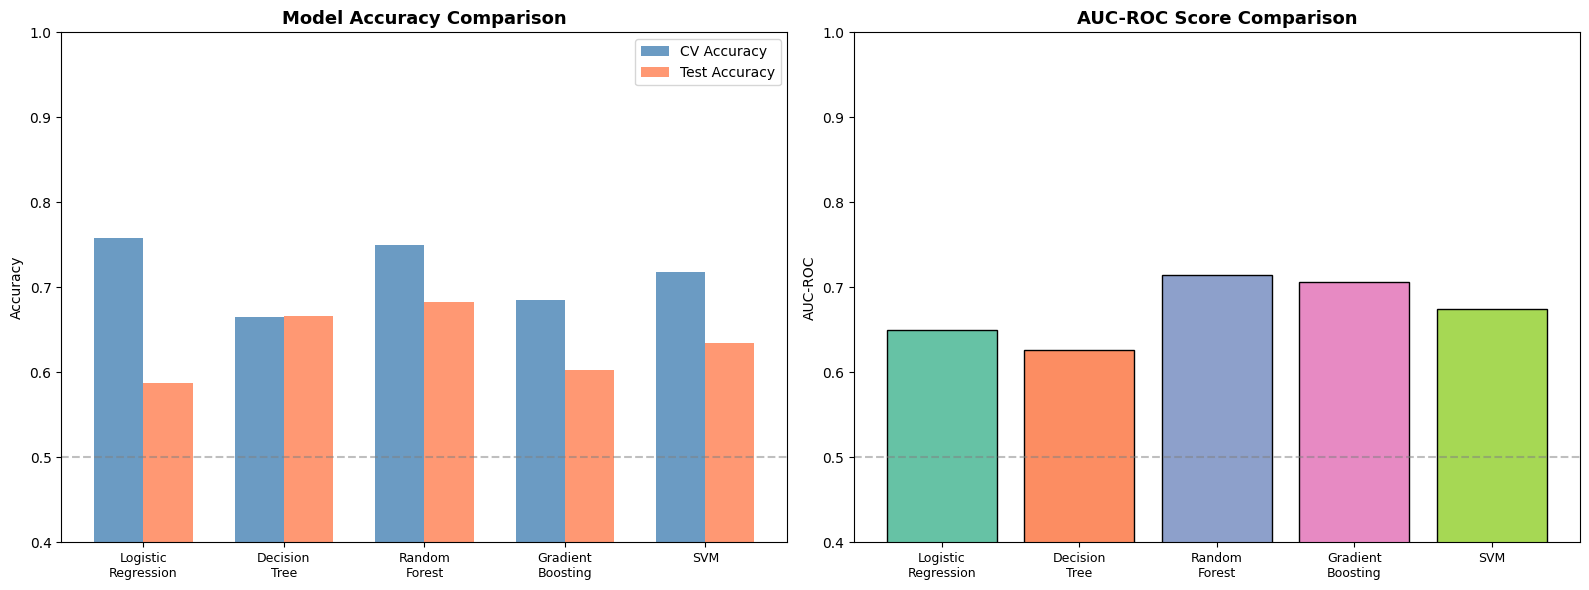

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = list(results.keys())
test_accs = [results[m]['test_accuracy'] for m in model_names]
aucs = [results[m]['auc_roc'] for m in model_names]
cv_means = [results[m]['cv_mean'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = axes[0].bar(x - width/2, cv_means, width, label='CV Accuracy', color='steelblue', alpha=0.8)
bars2 = axes[0].bar(x + width/2, test_accs, width, label='Test Accuracy', color='coral', alpha=0.8)
axes[0].set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=9)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.4, 1.0)
axes[0].legend()
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Baseline (50%)')

# AUC-ROC
axes[1].bar(model_names, aucs, color=sns.color_palette('Set2', 5), edgecolor='black')
axes[1].set_title('AUC-ROC Score Comparison', fontsize=13, fontweight='bold')
axes[1].set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=9)
axes[1].set_ylabel('AUC-ROC')
axes[1].set_ylim(0.4, 1.0)
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('E:/PSL_Predictor/outputs/plots/08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 5: Best Model — Detailed Evaluation

In [8]:
# Best model select karo (highest test accuracy)
best_name = max(results, key=lambda k: results[k]['test_accuracy'])
best = results[best_name]
print(f'🏆 Best Model: {best_name}')
print(f'   Test Accuracy: {best["test_accuracy"]:.3f}')
print(f'   AUC-ROC: {best["auc_roc"]:.3f}')
print()
print('Classification Report:')
print('='*50)
print(classification_report(y_test, best['y_pred'],
                            target_names=['2nd Innings Team Wins', '1st Innings Team Wins']))

🏆 Best Model: Random Forest
   Test Accuracy: 0.683
   AUC-ROC: 0.714

Classification Report:
                       precision    recall  f1-score   support

2nd Innings Team Wins       0.69      0.77      0.73        35
1st Innings Team Wins       0.67      0.57      0.62        28

             accuracy                           0.68        63
            macro avg       0.68      0.67      0.67        63
         weighted avg       0.68      0.68      0.68        63



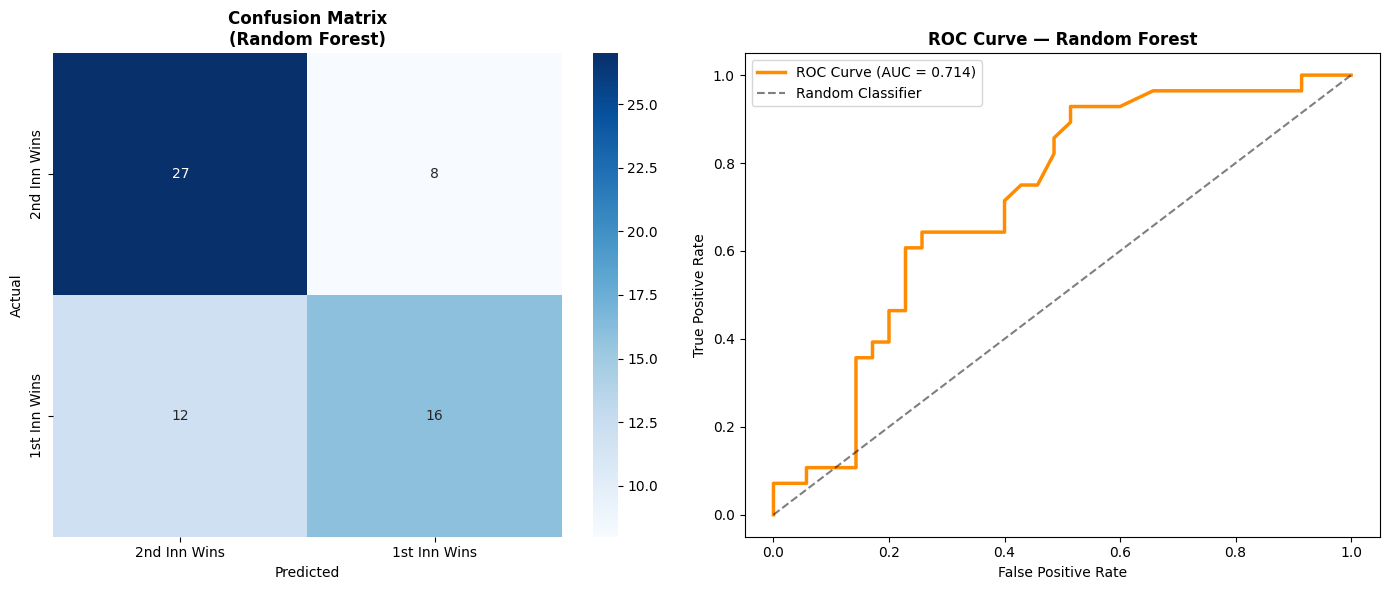

In [9]:
# Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['2nd Inn Wins', '1st Inn Wins'],
            yticklabels=['2nd Inn Wins', '1st Inn Wins'])
axes[0].set_title(f'Confusion Matrix\n({best_name})', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, best['y_prob'])
axes[1].plot(fpr, tpr, linewidth=2.5, color='darkorange',
             label=f'ROC Curve (AUC = {best["auc_roc"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
axes[1].set_title(f'ROC Curve — {best_name}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('E:/PSL_Predictor/outputs/plots/09_best_model_eval.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 6: Feature Importance

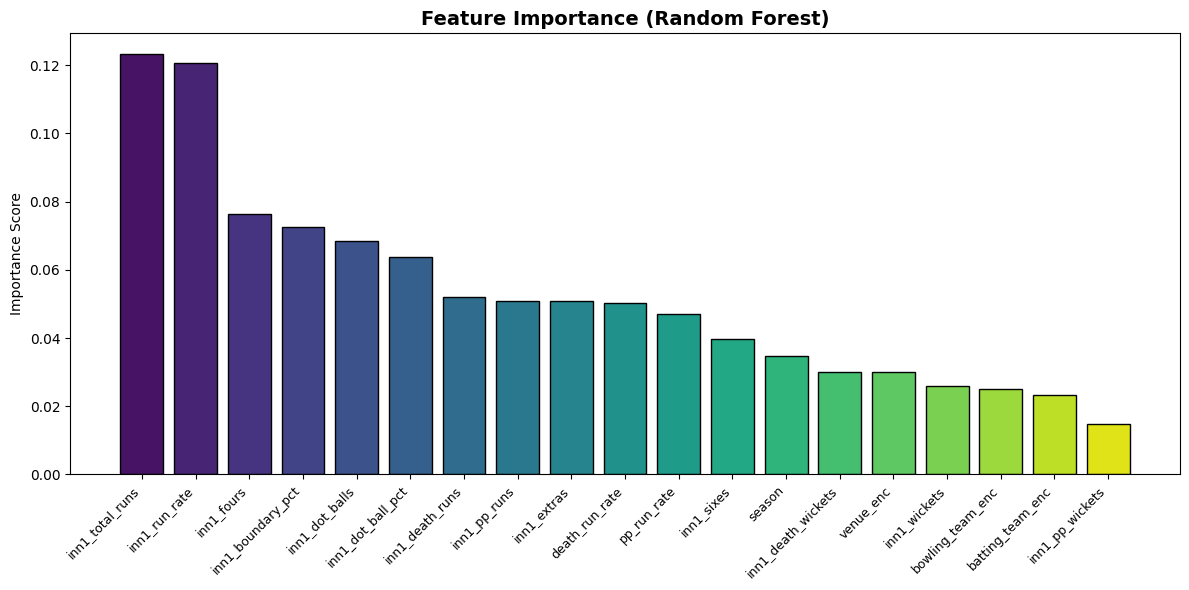

Top 5 Most Important Features:
  inn1_total_runs: 0.1232
  inn1_run_rate: 0.1208
  inn1_fours: 0.0764
  inn1_boundary_pct: 0.0727
  inn1_dot_balls: 0.0685


In [10]:
# Random Forest ka feature importance
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=FEATURES)
importances_sorted = importances.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(importances_sorted.index, importances_sorted.values,
               color=sns.color_palette('viridis', len(FEATURES)), edgecolor='black')
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('E:/PSL_Predictor/outputs/plots/10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 Most Important Features:')
for feat, imp in importances_sorted.head(5).items():
    print(f'  {feat}: {imp:.4f}')

### Step 7: Model Save Karo

In [ ]:
import joblib

# Best model save karo
joblib.dump(results['Random Forest']['model'], 'E:/PSL_Predictor/models/random_forest_model.pkl')
joblib.dump(scaler, 'E:/PSL_Predictor/models/scaler.pkl')

# Feature list bhi save karo
import json
with open('E:/PSL_Predictor/models/feature_list.json', 'w') as f:
    json.dump(FEATURES, f)

print('✅ Models saved!')
print('E:/PSL_Predictor/models/random_forest_model.pkl')
print('E:/PSL_Predictor/models/scaler.pkl')
print('E:/PSL_Predictor/models/feature_list.json')

FileNotFoundError: [Errno 2] No such file or directory: 'E:/PSL_Predictor/outputs/models/scaler.pkl'

## 🎉 Model Training Complete!
### Results Summary:
- Multiple models train aur evaluate kiye
- Confusion matrix, ROC curve, aur feature importance dekha
- Best model save ho gaya `outputs/models/` mein
- **Next:** Notebook 5 mein prediction function banana